In [2]:
""" Chapter 09: Unserpervised Learning Techniques """

# Unsupervised learning would be the cake,
# supervised Learing would be the icing on the cake, 
# and reinforcement learning would be the cherry on the cake

# Wouldn't it be great if the algorithm could just exploit the unlabled data without needing humans to labele every picture?
# that's unsupervised learning!

# - Clustering
# - Anomaly Detection or Outlier Detection
# - Density Estimation

' Chapter 09: Unserpervised Learning Techniques '

In [3]:
""" Clustering Algorithms: K-means and DBSCAN """

# It is the task of identifying similar instances and assigning them to clusters or groups of similar instances.
# Just like in classification, each instance gets assigned to a group,
# However, unlike classification, clustering is an unsupervised task.

# There're 2 side datasets = A labeled dataset and without the labels.
# Clustering algorithms can make good use of all features, so in fact they identify the three clusters fairly well.

# Clustering is used in a wide variety of applications,

# 1. Customer Segmentation = Can be useful in recommender systems to suggest content that other users in the same cluster enjoyed.
# 2. Data Analysis = Can be helpful to run a clustering algorithm, and then analyze each cluster separately.
# 3. Dimensionality Reduction = Measure each instances's affinity with each cluster; affinity is any measure of how well an instance fits into a cluster,
# 3.1 If there are k-clusters, then this vector is k-dimensional. The new vector is typically much lower-dimensional than the original feature vector, but it can preserve enough information for further processing.
# 4. Feature engineering = k-means add geographic cluster affinity features to the California housing dataset, and they helped us get better performance.
# 5. Anomaly Detection = If I have clustered the users of my website based on their behavior, I can detect users with unsual behavior, such as an unsual number of requests per second.
# 6. Semi-Supervised Learning = If i only have a few labels, I could perform clustering and propagate the labels to all the instances in the same cluster.
# 7. Search Engines = Some search engines let me search for images that are similar to a reference image. To build such a system, I would first apply a clustering algorithm to all the images in my dataset
# 7.1 Similar images would end up in the same cluster. Use it for trained clustering model to find the images'scluster and I could then simply return all the images from the cluster.
# 8. Image Segmentation = By clustering pixels according to their color, then replacing each pixel's color with the mean color of its cluster, it is possible to considerablhy reduce the number of different color in an image.

# Some alhorithms looks for instances centered around a particular point called "Centroid"


' Clustering Algorithms: K-means and DBSCAN '

In [4]:
""" K-Means """

# The k-means algorithm is a simple algorithm capable of clustering the kind of data that unlabeled dataset very quickly and efficiently,
# Often in just a few iteration
# K-means is sometimes referred to as the Lloyd-Forgy algorithm

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, centers=5, random_state=42) # set the parameters for make_blobs

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

# Note that I have to specify the number of clusters k that the algorithm must find.
# An instance's label is the index of the cluster to which the algorithm assigns this instance;
# This is not to be confused with the class labels in classification, which are used as targets 
# Remember that clustering is an unsupervised learning task

In [5]:
y_pred

array([1, 4, 0, 4, 3, 1, 2, 2, 2, 0, 0, 1, 4, 0, 2, 3, 4, 4, 1, 3, 3, 2,
       0, 1, 3, 3, 4, 4, 4, 2, 1, 3, 4, 4, 4, 3, 0, 0, 0, 2, 1, 2, 2, 2,
       3, 0, 0, 1, 3, 4, 4, 2, 2, 1, 2, 3, 4, 4, 0, 0, 2, 0, 3, 1, 3, 1,
       4, 4, 1, 4, 3, 1, 1, 1, 4, 3, 2, 3, 4, 1, 4, 1, 3, 2, 3, 0, 3, 0,
       0, 0, 3, 0, 1, 2, 1, 0, 1, 0, 2, 2], dtype=int32)

In [6]:
y_pred is kmeans.labels_

True

In [7]:
# Take a look at the five centroids that the algorithm found:

kmeans.cluster_centers_

array([[-2.87559086,  8.66758942],
       [-6.88732163, -6.84846391],
       [ 4.73987759,  2.0192694 ],
       [-8.97484095,  7.55134937],
       [ 1.90144007,  4.22597687]])

In [8]:
# Assign a new instances to the cluster whose centroid is closet:
import numpy as np
X_new = np.array([[0,2], [3,2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([4, 2, 4, 4], dtype=int32)

In [9]:
# The k-means algorithm does not behave very well when the blobs have very different diameters because all it care about
# when assigning an instance to a cluster is the distance to the centroid
# Instead of assigning each instace to a single cluster, which is called "hard-clustering",
# it can be useful to give each instance a score per cluster, which is called "soft-clustering"

# The transform() method measures the distance from each instance to every centroid:

kmeans.transform(X_new).round(2)

array([[ 7.26, 11.21,  4.74, 10.55,  2.93],
       [ 8.89, 13.27,  1.74, 13.2 ,  2.48],
       [ 5.67, 10.59,  7.8 ,  7.51,  5.05],
       [ 6.17, 10.12,  7.75,  7.82,  5.2 ]])

In [10]:
# If you have a high-dimensional dataset and you transform it this way, you end up with a "k-dimensional" datasets
# This transformation can be a very efficient nonlinear dimensionality reduction technique

In [11]:
""" The k-means algorithm """


# If I were given all the instance labels, I could easily locate each cluster's centroid by computing the mean of the instances in that cluster
# Start by placing the centroids randomly by picking k instances at random from the dataset and using their locations as centroids.
# Then label the instances, update the centroids, label the instances, update the centroids, and so on untill the centroids stop moving
# the mean square distance between the instance and their closet centroids can only go down at each step and since it cannot be negative
# It's guaranteed to converge.

# The computational complexity of the algorithm is generally linear with regard to the number of instances m,
# The number of clusters k,
# and the number of dimensions n.

# This is only true when the data has a clustering structure.
# If it does not
# the complexity can increase exponentially with the number of instances.
# K-means is generally one of the fastest clustering algoritms!

' The k-means algorithm '

In [12]:
""" Controid Innitialization Methods """

# Set the init hyperparameter to a NumPy array containing the list of centroids and set n_init to 1:

good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.","array([[-3, ... [ 0, 2]])"
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [13]:
# Another solution is to run the algorithm multiple times with different random initializations and keep the best solution.
# n_init hyperparameter: by default it is equal to 10,
# the whole algorithm described earlier runs 10 times when yuo call fit().
# Scikit-Learn keeps the best solutions.

# The KMeans class runs the algorithm n_init times and keeps the model with the lowest inertial.
# A model's inertia is accessible via the innertia_instance ravieble:

kmeans.inertia_

653.4766691679386

In [14]:
# The score() method returns the negative inertia

kmeans.score(X)

-653.4766691679386

In [15]:
# k-means ++
# A smarter initialiazation step that tends to select centroids that are distant from one another,
# And this improvement makes the k-means algorithm much less likely to converge to a suboptimal solution.

In [16]:
""" Accelerated k-means and Mini-batch k-means """

# some large datasets with many clusters, the algorithm can be accelerated by avoiding many unneccessary distance calculations.
# Elkan's algorithm does not always accelerate training and sometimes it can even slow down training significantly.
# It depends on the dataset.

# The algorithm is capable of using mini-batches, moving the centroids just slightly at each iteration.
# Makes it possible to cluster huge datasets that do not fit in memory.

from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",42
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


In [17]:
# The mini-batch k-means algorithm is much faster than the regular k-means algorithm, its inertia is generally slightly worse.

In [18]:
""" Finding the Optimal Number of Clusters """

# We've set the number of clusters k to 5 because it was obvious by looking at the data that this was the correct answer of clusters.
# But in general it won't be easy to know how to set k, and the result might be quite bad if you set it to the wrong value.

# the inertia for k=3 is about 653.2, which is much higher than for k=5 about 211.6
# But with k=8 the inertia is just 119.1. The inertia is not a good performance metric when trying to choose k because...
# It keeps getting lower as we increase k
# The more clusters there are, the closer each instance will be to its closest centroid and therefore the lower the indertia will be.





' Finding the Optimal Number of Clusters '

In [19]:
# Any lower value would be dramatic, while any higher value would not help much, adn we might just be splitting perfectly good clusters in half for no good reason.
# Use the silhouette score, which is the mean silhouette coefficient over all the instances.
# An instance's silhouette coefficient is (b - a) / max(a, b) where a is the mean distance to the other instances in the same cluster.
# And B is the mean nearest-cluster distance instances of the next closet cluster, defined as the one that minimizes b.

# The silhouette coefficient can vary between -1 and +1
# A coefficient close to +1 means that the instance is well inside its own cluster and far from other clusters
# A coefficient close to 0 means that it is close to a cluster boundary; finally.
# A coefficient close to -1 means that the instance may have been assigned to the wrong cluster.

from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.5895775795724798

In [20]:
# Silhouette Diagram

# Each diagram contains one knife shape per cluster.
# The shape's height indicates the number of instances in the cluster, and its width represents the sorted silhouette coefficient of the instances in the cluster 
# Wide is better.

# So, even though the overall silhouette score from k = 4 is slightly greater than for k = 5,
# it seems like a good idea to use k = 5 to get clusters of similar sizes.

In [21]:
""" Limits of K-means """

# K-means does not behave very well when the clusters have varying sizes, different dentsities or nonspherical shapes.
# It is important to scale the input feature before you run k-means or the cluster may be very stretched and k-means will perform poorly.
# Scaling the features does not guarantee that all the cluster will be nice and spherical, but it generally helps k-means.

' Limits of K-means '

In [22]:
""" Using Clustering for Image Segmentation """

# Image Segmentation is the task of partitioning an image into multiple segments.

# Color Segmentation: Pixels with a similar color get assigned to the same segment.
# Semantic Segmentation: All pixels that are part of the same object type get assigned to the same segment.
# Instance Segmentation: All pixels that are part of the same individual object are assigned to the same segment.

# Pillow package = A Successor to the Python Imagine Library, PIL.
import numpy as np
from PIL import Image
import urllib.request

# 1. ดาวน์โหลดรูปภาพตัวอย่างเข้ามาในโฟลเดอร์
url = "https://github.com/ageron/handson-ml3/raw/main/images/unsupervised_learning/ladybug.png"
urllib.request.urlretrieve(url, "ladybug.png")

# 2. กำหนด Path ของไฟล์รูปภาพ
filepath = "ladybug.png"

# 3. โหลดรูปภาพด้วย Pillow และแปลงเป็น NumPy Array
image = np.asarray(Image.open(filepath))

# 4. ตรวจสอบมิติ/ขนาดของรูปภาพ (Height, Width, Channels)
image.shape

(533, 800, 3)

In [23]:
# A 3D vector containing the intensities of Red, Green, Blue or RGB as unsigned 8-bit intergers between 0 and 255.
# The following code reshapes the array to get a long list of RGB color, then it clusters these colors using k-means with 8 clusters.
# It reshapes this array to the original image shape.

from sklearn.cluster import KMeans

# แปลงอาร์เรย์รูปภาพให้อยู่ในรูปรายการของค่าสี RGB (ยาว N, 3)
X = image.reshape(-1, 3)

# เติม s ที่ n_clusters
kmeans = KMeans(n_clusters=8, random_state=42).fit(X)

# แทนค่าพิกเซลเดิมด้วยค่าเฉลี่ยสี (Centroid) ของกลุ่มนั้นๆ
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

In [24]:
# K-means perfers clusters of similar sizes.

In [25]:
""" Using Clustering for Semi-Supervised Learning """

# Use this when we have plenty of unlabeled instances and very few labeled instances.

from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [26]:
# We will pretent we hav labels for 50 intances. To get a baseline performance

from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
# Measure the accuracy of this model on the test set

log_reg.score(X_test, y_test)

0.7581863979848866

In [28]:
# not that good right but maybe train the full model would be good
# Let's cluster the training set into 50 clusters.
# For each cluster, we will find the image closest to the controid.

k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

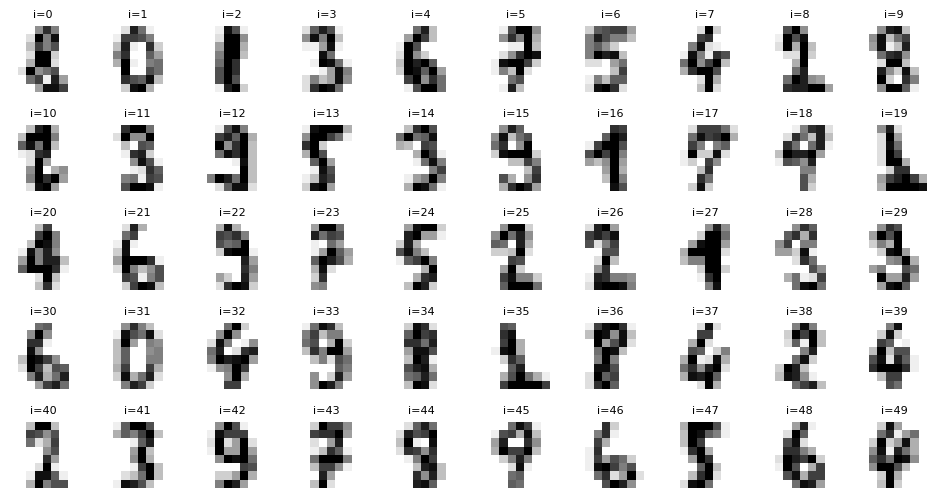

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i, image_data in enumerate(X_representative_digits):
    plt.subplot(5, 10, i + 1)
    plt.imshow(image_data.reshape(8, 8), cmap="binary")
    plt.title(f"i={i}", fontsize=8) # บอกชัดๆ ว่ารูปนี้คือ index ไหน
    plt.axis('off')
plt.subplots_adjust(hspace=0.5)
plt.show()

In [30]:
# Let's check each image and manually label:

y_representative_digits = np.array([
    # i=0 ถึง 9
    8, 0, 1, 3, 6, 2, 5, 4, 1, 8,
    # i=10 ถึง 19
    2, 3, 9, 5, 3, 9, 1, 7, 9, 1,
    # i=20 ถึง 29
    4, 6, 5, 7, 5, 2, 2, 1, 3, 3,
    # i=30 ถึง 39
    6, 0, 4, 9, 8, 1, 8, 4, 2, 4,
    # i=40 ถึง 49
    2, 3, 9, 7, 8, 9, 6, 5, 6, 4
])

In [31]:
# Each of them is a representative image of its cluster. Let's see if the. performance is any better:

log_reg = LogisticRegression(max_iter=100)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

/Users/nattawut/Python-Training/ScikitLearn-Keras-TensorFlow/ML_train/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8136020151133502

In [32]:
# It is a good idea to label representative instances rather than just random instances!
# What if we propagated the labels to all the other instances in the same cluster?
# Label Propagation:

y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [33]:
# Train again and observe the performance.

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/Users/nattawut/Python-Training/ScikitLearn-Keras-TensorFlow/ML_train/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7858942065491183

In [34]:
# Computes the distance from each instance to its closest cluster center, then for each cluster it sets the 1% largest distances to -1

percentile_closest = 99

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [35]:
# Train the model on this partially propagated dataset and see the accuracy:

log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.7858942065491183

In [36]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()
# drop some outliers and partly the propagated labels

np.float64(0.8925925925925926)

In [37]:
# Active Learning which is when a human expert interacts with the learning algorithm providing labels for specific instances when the algorithm request them
# 1. The model is trained on the labeled instances gathered so far, and this model is used to make prediction on all the unlabeled instances
# 2. The instances for which the model is most uncertain are given to the expert for labeling
# 3. You iterate this process until the performance improvement stops being worth the labeling effort.

# I can try labeling the instances that would result in the largest model change or the larget drop in the model's validate error,
# or the instances that different models disagree on

In [38]:
""" DBSCAN """

# Density-based spatial clustering of applications with noise

# 1. For each instance, the algorithm counts how many instances are located within a small distance e (epsilon) from it = e-neightborhood
# 2. If an instance has at least min_samples instances in its e-neightborhood including itself then it is considered a core instance
# 3. All instance in the neightborhood of a core instance belong to the same cluster. A long sequence of neighboring core instances forms a single cluster.
# 4. Any instance that is not a core instance and does not have one in its neighbor hood is considered an anomaly.

# This algorithm works well if all the clusters are well separated by low-density regions!

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.05
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [39]:
dbscan.labels_

array([ 0,  1,  2,  3,  4,  4,  4,  5,  5,  3,  1,  5,  6, -1,  1,  1,  6,
        2,  4,  3,  4,  1,  4,  3,  4,  3,  1,  1,  5,  1,  5,  3,  4,  6,
        4,  0,  2,  5,  2,  1,  6,  6,  4,  2,  4,  5,  5,  4,  2,  4,  4,
        1,  4,  2,  0,  6,  4,  6,  2,  5,  4,  3,  5,  4,  4,  5, -1,  4,
        2,  2,  0,  3,  4,  3,  0,  5,  2,  4,  5,  4,  4,  1,  2,  2,  6,
       -1,  6,  5,  4,  4,  1,  5,  5,  4,  5,  3,  0,  4,  1, -1,  4, -1,
       -1,  0, -1,  4,  5,  3,  6,  0,  4,  4,  2, -1,  5,  1,  0,  5, -1,
        4,  3,  5,  3,  2,  1,  5,  4,  1,  5,  3,  2,  2,  5,  0,  3,  2,
       -1,  5,  4, -1,  3,  0,  6,  4,  4, -1,  4,  4,  4,  6,  1,  4,  3,
        6,  4,  1,  1,  6,  5,  2,  2,  4,  5,  2,  5,  2,  2,  1,  0,  5,
       -1,  5,  4,  4,  6,  4,  0,  5,  0,  4,  3,  4,  4,  3,  5,  5,  2,
        0,  0,  2,  4, -1,  4,  4,  4,  5,  4,  5,  4,  2,  1,  3,  1,  4,
        2,  5, -1,  5,  4,  5, -1,  3,  4,  4, -1,  5,  2, -1,  0, -1,  5,
        6,  6,  6,  4,  2

In [40]:
# A cluster index equal to -1, which means that they are considered as anomalies by the algorithm.

dbscan.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   8,  10,  11,  12,  14,  15,
        16,  17,  18,  19,  20,  21,  22,  24,  25,  26,  27,  28,  29,
        30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  41,  42,  43,
        44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  55,  56,  57,
        58,  59,  60,  61,  62,  63,  64,  65,  68,  69,  70,  71,  73,
        74,  75,  76,  77,  78,  79,  80,  81,  83,  84,  86,  87,  88,
        89,  90,  92,  94,  95,  96,  97,  98, 100, 103, 106, 107, 108,
       109, 110, 112, 114, 115, 116, 117, 119, 120, 121, 122, 123, 124,
       125, 127, 128, 129, 130, 131, 132, 134, 135, 137, 138, 140, 141,
       142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 158, 159, 160, 161, 162, 163, 164, 165, 167, 168, 169, 171,
       172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184,
       185, 186, 187, 189, 190, 193, 194, 195, 197, 198, 199, 200, 202,
       203, 204, 207, 208, 209, 212, 213, 215, 216, 218, 221, 22

In [41]:
dbscan.components_

array([[ 0.10319049, -0.07630349],
       [ 0.4349666 , -0.25997864],
       [ 1.73914527, -0.25069807],
       ...,
       [ 0.97402341,  0.21997995],
       [ 0.10939215,  0.13255791],
       [ 1.98477709,  0.37050414]], shape=(810, 2))

In [42]:
# the DBSCAN class doe not have a predict() method, although it has a fit_predict() method. In other words, 
# It cannot predict which cluster a new instance belong to.

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [43]:
# I can predict which clusters they most likely belong to and even estimate a probability for each cluster:

X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([5, 0, 4, 3])

In [44]:
knn.predict_proba(X_new)

array([[0.28, 0.  , 0.  , 0.  , 0.  , 0.72, 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.06, 0.24, 0.  , 0.7 , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 1.  , 0.  , 0.  , 0.  ]])

In [45]:
# Note that we only trained the classifier on the core instances,
# but we could also have chosen to train it on all the instances, or all the but the anomalies.

In [46]:
# Since there is no anomaly in the training set, the classifer always chooses a cluster, even when that cluster is far away.

y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  4, -1])

In [47]:
# DBSCAN is a very simple yey powerful algorithm capable of identifying any number of clusters of any shape.
# It is robust to outliers and it has just 2 hyperparameter: eps / min_samples

# If the density varie significantly across the clusters,
# If there's no sufficiently low-density region around some clusters.
# DBSCAN can struggle to capture all the clusters properly

# Computation complexity is roughly O(m^2n) so it does not scale well to large datasets.

In [48]:
""" Other Clustering Algorithms """

# 1. Agglomerative Clustering
# A hierachy of cluster is built from the bottom up. Think of many tiny bubbles floating on water and gradually attaching to each other untill there's one big group of bubbles.
# If you drew a tree with a branch for every pair of clusters that merged, you would get a binary tree of clusters where the leaves are the individual instances.
# It can scale nicely to large numbers of instances if I provide a conectivity matrix, wihch is a sparse m X n matrix that indicates which pairs of instnaces are negihtbors.
# Without a connectivity matrix, the algorithm does not scale well to large datasets.

# 2. BIRTCH
# The balanced iterative reducing and clustering using hierarchies (BIRCH) alsorithm was designed specifically for every large datasets and it can be faster than batch k-means.
# With similar results, as long as the number of feature is not too large <20.
# It build tree structure containing just enough information to quickly assign each new instance to a cluster, without having to store all the instances in the tree

# 3. Mean-Shift
# Placing a circle centered on each instance; then for each circle it computes the mean of all the instances located within it, and it shifts the circle so that it is centered on the mean.
# Next, it iterates this mean-shifting step untill all the circles top moving
# Mean-shift shifts the circles in the direction of higher density untill each of them has found a local density maxximum
# All the instances whose circles have settled in the same place are also assigned to the same cluster
# O(m^2n) os it is not suited for large datasets.

# 4. Affitini propagation
# In politics, you typically want to vote for a candidate whose opinions are similar to me, but I also want them to win the election,
# So I migh choose a candidate I don't fully agree with, but who is more popular.
# You typically evaluate popularity thorough polls Affinity porpagation works in a similar way, it tend to choose exemplars located near the center of clusters
# similar to k-means but unlike with k-means I dont have to pich a number of clusters ahead of time.
# O(m^2n) not good for large datasets again.

# 5. Specral clusttering
# Spectral clustering can capture complex cluster structures and it can also be used to cut graphs
# such as to identify clusters of friends on a social network.

' Other Clustering Algorithms '

In [49]:
""" Gaussian Mixtures """
# A probabilistic model that assumes that the instances were generated from a mixture of several Gaussian distributions whoe parameters are unknow.
# All the instances generated from a single Gaussina distribution from a cluster that typically looks like an ellipsoid.
# Each cluster can have a different ellipsoidal shape, size, density, and orientation

# GaussianMixture class, I must know in advance the number k of Gausian distribution.

from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10)
gm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",10
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [50]:
# algorithm estimated:

gm.weights_

array([0.59864664, 0.19853643, 0.20281694])

In [51]:
gm.means_

array([[ 0.50563949,  0.24520118],
       [ 1.76174381, -0.05201243],
       [-0.74604752,  0.55563785]])

In [52]:
gm.covariances_

array([[[ 0.17388742, -0.10610376],
        [-0.10610376,  0.29080654]],

       [[ 0.04916806,  0.05796827],
        [ 0.05796827,  0.08245734]],

       [[ 0.05393297,  0.06361168],
        [ 0.06361168,  0.09160364]]])

In [54]:
# the cluster weight: 0.6, 0.2, 0.2
# This class relies on the expectation-maximization algorithm which has many similarities with the k-means algorithm.
# for each instance, during the expectation step, the algorithm estimates the probabilities that it belongs to each cluster based on the current cluster parameter
# Then, during the maximization step, each cluster is updated using all the instances in the dataset, with each instance weighted by the estimated probability that it belong to that cluster.
# These probabilities are called the "resposibilities" of the cluster for the instances.

In [55]:
# EM can end up converging to poor solutions so it needs to be run several times, keeping only the best solution.
# Let's check whether or not the algorithm converged and how many iteration it took:

gm.converged_

True

In [56]:
gm.n_iter_

17

In [57]:
# Use the predict() method for hard clustering or the predict_proba() method for soft clustering:

gm.predict(X)

array([0, 0, 1, 1, 0, 0, 0, 2, 2, 1, 0, 2, 2, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 2, 0, 2, 1, 0, 0, 0, 0, 1, 2, 1, 0, 2, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 2, 0, 2, 0, 1, 2, 0, 0, 2,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 2, 1, 0, 2, 0, 0, 0, 1, 1, 2, 0, 2, 2,
       0, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 2, 1, 2, 0,
       0, 0, 1, 2, 2, 0, 0, 2, 0, 0, 1, 2, 1, 1, 0, 2, 0, 0, 2, 1, 0, 1,
       2, 0, 1, 1, 0, 2, 0, 2, 1, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 2, 0, 2, 1, 1, 0, 0, 2, 1, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 1, 0, 0, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2,
       0, 0, 0, 1, 0, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 0, 2, 2, 0, 0, 0, 2,
       2, 2, 0, 2, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 1, 0, 2, 1,
       2, 0, 1, 0, 0, 2, 1, 0, 1, 1, 0, 1, 2, 2, 0, 2, 1, 0, 0, 1, 1, 2,
       1, 2, 0, 2, 2, 0, 1, 0, 0, 1, 0, 2, 2, 1, 1, 0, 2, 2, 0, 0, 0, 1,
       0, 1, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,

In [58]:
gm.predict_proba(X).round(3)

array([[1.   , 0.   , 0.   ],
       [1.   , 0.   , 0.   ],
       [0.012, 0.988, 0.   ],
       ...,
       [1.   , 0.   , 0.   ],
       [1.   , 0.   , 0.   ],
       [0.   , 1.   , 0.   ]], shape=(1000, 3))

In [59]:
# A Gaussian mixture model is a generative model, I acn sample new instances from it
# they are ordered by cluster index:

X_new, y_new = gm.sample(6)
X_new

array([[ 1.1723772 ,  0.08488603],
       [-0.02980125,  0.23949114],
       [ 1.30289159,  0.22779334],
       [ 0.12287655,  1.14692943],
       [ 0.58004422, -0.27328203],
       [ 0.24399776,  0.70822581]])

In [60]:
y_new

array([0, 0, 0, 0, 0, 0])

In [61]:
# Estimates the log of the probabilities density function or PDF at the location.
# The bigger the score -> The higher the density
gm.score_samples(X).round(2)

array([-1.91, -1.41, -0.86,  0.05, -1.43, -1.39, -1.85, -1.98, -0.75,
       -0.04, -1.69, -0.28, -1.12, -2.11, -1.54, -1.57, -1.37, -1.85,
       -1.39, -1.11, -1.52, -1.73, -1.47, -1.53, -1.51, -1.46, -1.69,
       -1.76, -0.92, -1.51,  0.06, -1.04, -1.56, -2.22, -1.41, -1.64,
       -0.77, -0.27,  0.11, -1.56, -0.75, -2.19, -1.87, -2.13, -1.32,
       -0.62,  0.02, -1.79, -1.97, -1.63, -1.72, -1.62, -1.69, -0.54,
       -1.41, -0.59, -1.55, -0.65, -2.2 , -0.1 , -1.85,  0.17, -0.44,
       -1.8 , -1.61, -0.19, -1.32, -1.34, -1.97, -1.98, -1.63, -1.5 ,
       -1.75, -0.57, -1.41, -0.66, -0.26, -1.66, -0.03, -1.47, -1.49,
       -1.58, -1.47, -0.08, -0.46, -1.19, -0.65, -1.13, -1.72, -1.44,
       -1.69, -0.03, -1.1 , -1.51, -0.51, -1.09, -1.66, -1.52, -1.95,
       -1.3 , -1.81, -1.98, -1.93, -1.63, -0.17, -2.03, -1.  , -1.27,
       -1.17, -1.52, -1.5 , -1.42, -1.4 , -0.81, -0.57, -1.66, -1.36,
       -0.64, -2.05, -1.61, -0.08, -2.48, -0.48, -0.25, -1.48, -0.15,
       -1.25, -1.75,

In [62]:
# To estimate the probability that an instance will fall within a particular region, I would have to integrate the PDF over that region.

In [63]:
# Unfortunately, Read-world data is not always so Gaussian and low-dimensional.
# I might need to reduce the difficulty of the task by limiting the number of parameters that the algorithm has to learn.
# One way to do this is to limit the range of shapes and orientations that the clusters can have.

# spherical = All clusters must be spherical, but they can have different diameters.
# diag = Clusters can take on any ellipsoidal shape of any size, but the ellipsoid's axes must be parallel to the coordinate axes
# tied = All clusters must have the same ellipsoidal shape, size, and orientationl

# covarince_type = "full" => each cluster can take on any shape, size, and orientation it has its own unconstrained covarience matrix.
# O(kmn^2 + kn^3) = not scale to large numbers of features.